# 2x2 MMI power splitter

In this notebook, we will design and simulate a 2x2 Multi-Mode Interference (MMI) power splitter for photonic integrated circuits (PICs). The MMI power splitter is a fundamental component in integrated photonics, providing equal power splitting (50/50) with high efficiency and broadband performance.

The design follows standard Silicon-on-Insulator (SOI) platform specifications with professional cosine S-bends for optimal performance. We will demonstrate the complete simulation workflow including geometry setup, wavelength sweep analysis, and performance evaluation.

For more integrated photonic examples such as the 8-Channel mode and polarization de-multiplexer, the broadband bi-level taper polarization rotator-splitter, and the broadband directional coupler, please visit our [examples page](https://www.flexcompute.com/tidy3d/examples/).

If you are new to the finite-difference time-domain (FDTD) method, we highly recommend going through our [FDTD101 tutorials](https://www.flexcompute.com/tidy3d/learning-center/fdtd-101/).

FDTD simulations can diverge due to various reasons. If you run into any simulation divergence issues, please follow the steps outlined in our [troubleshooting guide](https://www.flexcompute.com/tidy3d/learning-center/troubleshooting/) to resolve it.

<img src="img/mmi_power_splitter_2x2.png" alt="Schematic of the 2x2 MMI Power Splitter"  width="400"/>


## Standard Python Imports

We start by importing the necessary libraries for our simulation.


In [1]:
# Standard python imports.
import gdstk
import matplotlib.pylab as plt
import numpy as np

# Import regular tidy3d.
import tidy3d as td
import tidy3d.web as web


## MMI Power Splitter Structure

The 2x2 MMI power splitter is based on a standard Silicon-on-Insulator (SOI) wafer with a device layer of 220 nm. The MMI section provides multimode interference for equal power splitting, while professional cosine S-bends route the output signals to offset positions for practical device integration.

**Key Design Parameters:**
- **Material Platform**: Silicon-on-Insulator (SOI)
- **Wavelength Range**: 1.5 to 1.6 μm (telecom C-band)
- **Design Goal**: Equal power splitting (50/50)
- **Features**: Professional cosine S-bends, wavelength sweep analysis

The MMI length is designed to achieve optimal interference patterns for equal power splitting, while the S-bends provide smooth transitions to offset output waveguides.


In [2]:
# MMI power splitter setup.
wavelength = 1.55  # Center simulation wavelength (μm).
freq0 = td.C_0 / wavelength  # Central frequency.


In [3]:
# Materials.
n_si = 3.48  # Silicon refractive index.
n_sio2 = 1.44  # SiO2 refractive index.

# Material definitions.
mat_si = td.Medium(permittivity=n_si**2)  # Silicon waveguide material.
mat_sio2 = td.Medium(permittivity=n_sio2**2)  # SiO2 substrate material.


In [4]:
# Complete simulation setup from working script
# This cell contains all the geometry, sources, monitors, and simulation creation

# MMI power splitter dimensions.
w_wg = 0.4      # Waveguide width (μm).
h_si = 0.22     # Silicon layer height (μm).
w_mmi = 1.0     # MMI section width (μm).
l_mmi = 3.0     # MMI section length (μm).
gap = 0.2       # Gap between output waveguides (μm).

# Waveguide lengths.
l_input = 2.0    # Input waveguide length (μm).
l_output = 3.0   # Output waveguide length (μm).

# S-bend parameters.
s_bend_offset = 1.0  # Lateral offset for S-bends (μm).
s_bend_length = 4.0  # Length of S-bend section (μm).


## Professional Cosine S-bend Function

We define a professional cosine S-bend function for smooth waveguide transitions. This function creates high-quality S-bends that minimize insertion loss and maintain good mode matching.


In [5]:
# Function to create professional cosine S-bends.
def cosine_sbend(x0, y0, z0, wg_width, wg_thickness, bend_length, bend_height, medium, orientation="x", mirror=False, sidewall_angle=0):
    """Professional cosine S-bend function for smooth waveguide transitions."""
    cell = gdstk.Cell("bend")
    path = gdstk.RobustPath((x0, y0), wg_width, layer=1, datatype=0)

    if orientation == "x":
        path.segment(
            (x0 + bend_length, y0),
            offset=lambda u: -bend_height * np.cos(np.pi * u) / 2 + bend_height / 2,
        )
        if mirror:
            path.mirror((x0 + 1, y0), (x0, y0))
    elif orientation == "y":
        path.segment(
            (x0, y0 + bend_length),
            offset=lambda u: -bend_height * np.cos(np.pi * u) / 2 + bend_height / 2,
        )
        if mirror:
            path.mirror((x0, y0 + 1), (x0, y0))

    cell.add(path)
    bend_geo = td.PolySlab.from_gds(
        cell,
        gds_layer=1,
        axis=2,
        slab_bounds=(z0 - wg_thickness / 2, z0 + wg_thickness / 2),
        sidewall_angle=sidewall_angle,
    )
    return td.Structure(geometry=bend_geo[0], medium=medium)


## Complete MMI Power Splitter Simulation Setup

Now we create the complete 2x2 MMI power splitter simulation with x-axis propagation. The simulation includes the MMI section, input/output waveguides, professional cosine S-bends, sources, and monitors.


In [6]:
# Calculate optimized simulation domain size for x-axis propagation.
x_min = -1.5 - 3.0  # -4.5 μm
x_max = 5.5 + 3.0   # 8.5 μm
total_length = x_max - x_min  # 13.0 μm
total_width = w_mmi + 4.0  # Keep width buffer for offset waveguides
total_height = 2.0  # Sufficient for SOI structure
sim_size_optimized = (total_length, total_width, total_height)

# 1. MMI section (main multimode interference region).
mmi_section = td.Structure(
    geometry=td.Box(center=(0, 0, 0), size=(l_mmi, w_mmi, h_si)),
    medium=mat_si
)

# 2. Output S-bend 1 (connects MMI top edge to bottom-side waveguide).
output_s_bend_1 = cosine_sbend(
    x0=l_mmi/2,  # Start at MMI right edge (x-axis propagation)
    y0=w_wg/2 + gap/2,  # Start at MMI top edge
    z0=0, wg_width=w_wg, wg_thickness=h_si, bend_length=s_bend_length,
    bend_height=s_bend_offset, medium=mat_si, orientation="x", mirror=False
)

# 3. Output waveguide 1 (connects to MMI top edge, positioned on bottom side).
output_wg_1 = td.Structure(
    geometry=td.Box(
        center=(l_mmi/2 + s_bend_length + l_output/2, w_wg/2 + gap/2 + s_bend_offset, 0),
        size=(l_output, w_wg, h_si)
    ), medium=mat_si
)

# 4. Output S-bend 2 (connects MMI bottom edge to top-side waveguide).
output_s_bend_2 = cosine_sbend(
    x0=l_mmi/2,  # Start at MMI right edge (x-axis propagation)
    y0=-w_wg/2 - gap/2,  # Start at MMI bottom edge
    z0=0, wg_width=w_wg, wg_thickness=h_si, bend_length=s_bend_length,
    bend_height=-s_bend_offset, medium=mat_si, orientation="x", mirror=False
)

# 5. Output waveguide 2 (connects to MMI bottom edge, positioned on top side).
output_wg_2 = td.Structure(
    geometry=td.Box(
        center=(l_mmi/2 + s_bend_length + l_output/2, -w_wg/2 - gap/2 - s_bend_offset, 0),
        size=(l_output, w_wg, h_si)
    ), medium=mat_si
)

# 6. Create input waveguides using Tidy3D reflection transformation for x-axis propagation.
input_wg_1_geometry = output_wg_1.geometry.reflected(normal=(1, 0, 0))
input_wg_1 = td.Structure(geometry=input_wg_1_geometry, medium=mat_si)
input_wg_2_geometry = output_wg_2.geometry.reflected(normal=(1, 0, 0))
input_wg_2 = td.Structure(geometry=input_wg_2_geometry, medium=mat_si)
input_s_bend_1_geometry = output_s_bend_1.geometry.reflected(normal=(1, 0, 0))
input_s_bend_1 = td.Structure(geometry=input_s_bend_1_geometry, medium=mat_si)
input_s_bend_2_geometry = output_s_bend_2.geometry.reflected(normal=(1, 0, 0))
input_s_bend_2 = td.Structure(geometry=input_s_bend_2_geometry, medium=mat_si)

# 7. Combine all structures.
mmi_structures = [input_s_bend_1, input_wg_1, input_s_bend_2, input_wg_2, mmi_section, 
                 output_s_bend_1, output_wg_1, output_s_bend_2, output_wg_2]

# 8. Create frequency array for wavelength sweep.
wavelengths = np.arange(1.5, 1.601, 0.001)  # 1.5 to 1.6 μm with 1 nm steps
frequencies = td.C_0 / wavelengths

# 9. Mode source at the upper input waveguide (x-axis propagation).
source_position = (-6, 1.3, 0)
source_size = (0, 6 * w_wg, 6 * h_si)
mode_source = td.ModeSource(
    center=source_position, size=source_size,
    source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0/10),
    direction="+", mode_spec=td.ModeSpec(num_modes=1), mode_index=0
)

# 10. Mode monitors at the output waveguides (x-axis propagation).
monitor_1_position = (l_mmi/2 + s_bend_length + 0.5, w_wg/2 + gap/2 + s_bend_offset, 0)
monitor_1_size = (0, 6 * w_wg, 6 * h_si)
mode_monitor_1 = td.ModeMonitor(
    center=monitor_1_position, size=monitor_1_size, freqs=frequencies,
    mode_spec=td.ModeSpec(num_modes=1), name="mode_output_1"
)

monitor_2_position = (l_mmi/2 + s_bend_length + 0.5, -w_wg/2 - gap/2 - s_bend_offset, 0)
monitor_2_size = (0, 6 * w_wg, 6 * h_si)
mode_monitor_2 = td.ModeMonitor(
    center=monitor_2_position, size=monitor_2_size, freqs=frequencies,
    mode_spec=td.ModeSpec(num_modes=1), name="mode_output_2"
)

# 11. Field monitor at xy plane - record fields at specific wavelengths (x-axis propagation).
field_freqs = [td.C_0 / 1.55, td.C_0 / 1.58]  # 1.55 and 1.58 μm
field_monitor = td.FieldMonitor(
    center=(0, 0, 0), size=(td.inf, td.inf, 0), freqs=field_freqs, name="field_xy"
)

# 12. Create the complete simulation.
sim_mmi = td.Simulation(
    size=sim_size_optimized, structures=mmi_structures, sources=[mode_source],
    monitors=[mode_monitor_1, mode_monitor_2, field_monitor], run_time=1e-12,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()), medium=mat_sio2,
    grid_spec=td.GridSpec(
        grid_x=td.AutoGrid(min_steps_per_wvl=20),
        grid_y=td.AutoGrid(min_steps_per_wvl=20),
        grid_z=td.AutoGrid(min_steps_per_wvl=20), wavelength=wavelength
    ), symmetry=(0, 0, 0)
)

# Simulation setup complete


## Simulation Visualization

Let's visualize the complete MMI power splitter setup to verify the geometry and propagation direction.


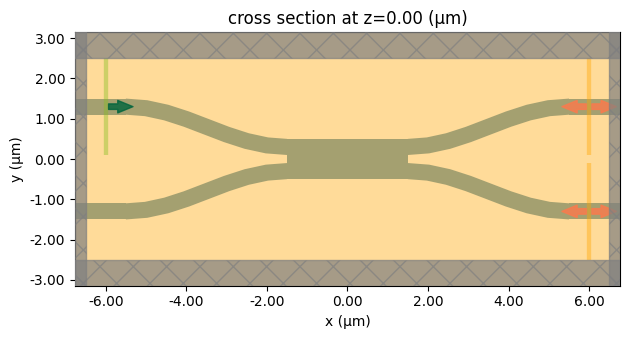

In [7]:
# Simulation Setup Visualization - XY Setup Plane
fig_xy = sim_mmi.plot(z=0)  # XY cross-section at z=0 (MMI center) - shows complete setup

In [8]:
# 3D Visualization
fig_3d = sim_mmi.plot_3d()

## Cost Estimation

Before running the simulation, let's estimate the computational cost.

In [9]:
# Cost Estimation
try:
    job = web.Job(simulation=sim_mmi, task_name="mmi_2x2_cost_estimation", verbose=True)
    cost_info = web.estimate_cost(job.task_id)
    print(f"Estimated cost: {cost_info:.4f} Flex Credits")
    
except Exception as e:
    print(f"Error in cost estimation: {e}")


20:17:18 -03 Created task 'mmi_2x2_cost_estimation' with task_id                
             'fdve-413673ba-bf14-4366-a34c-5b2931dfd000' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=714890;https://tidy3d.simulation.cloud/workbench?taskId=fdve-413673ba-bf14-4366-a34c-5b2931dfd000\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=904272;https://tidy3d.simulation.cloud/workbench?taskId=fdve-413673ba-bf14-4366-a34c-5b2931dfd000\taskId]8;;\]8;id=714890;https://tidy3d.simulation.cloud/workbench?taskId=fdve-413673ba-bf14-4366-a34c-5b2931dfd000\=]8;;\]8;id=451160;https://tidy3d.simulation.cloud/workbench?taskId=fdve-413673ba-bf14-4366-a34c-5b2931dfd000\fdve]8;;\]8;id=714890;https://tidy3d.simulation.cloud/workbench?taskId=fdve-413673ba-bf14-4366-a34c-5b2931dfd000\-413673ba-bf1]8;;\
             ]8;id=714890;https://tidy3d.simulation.cloud/workbench?taskId=fdve-413673ba-bf14-4366-a34c-5b2931dfd000\4-4366-a34c-5b2931dfd000']8;;\.

             Task folder: ]8;id=299904;https://tidy3d.simulation.cloud/folders/315b8f7e-fef5-4f8e-a0be-4c5a6c6f6194\'default']8;;\.

Output()

20:17:21 -03 Maximum FlexCredit cost: 0.103. Minimum cost depends on task       
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

20:17:22 -03 Maximum FlexCredit cost: 0.103. Minimum cost depends on task       
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

Estimated cost: 0.1030 Flex Credits


## Run Simulation

Now we run the simulation to obtain the results.

In [10]:
# Run Simulation
try:
    sim_data = job.run(path="mmi_2x2_results.hdf5")
    print("Simulation completed successfully!")
    
except Exception as e:
    print(f"Error during simulation execution: {e}")


20:17:23 -03 status = success

Output()

20:17:30 -03 loading simulation from mmi_2x2_results.hdf5

Simulation completed successfully!


## Result Analysis

Let's analyze the simulation results to evaluate the MMI power splitter performance.

**Key Performance Metrics:**

- **Power Splitting Ratio**: The fraction of total power that goes to each output port. For an ideal 2x2 MMI power splitter, both outputs should have a splitting ratio of 0.5 (50/50 split).

- **Splitting Imbalance**: The absolute difference between the two output power ratios. A perfect 50/50 splitter would have zero imbalance. Lower imbalance values indicate better power splitting performance.

- **Power Efficiency**: The ratio of total output power to input power, indicating how much power is lost during propagation through the device.

- **Total Power**: The sum of power from both output ports, showing the overall transmission efficiency of the device.

**Analysis Plots:**

The result analysis generates four key plots:

1. **Power Splitting vs Wavelength**: Shows how the splitting ratio varies across the wavelength range, with ideal 50/50 split indicated by the dashed line.

2. **Total Transmitted Power vs Wavelength**: Displays the total power transmission efficiency across wavelengths, indicating any wavelength-dependent losses.

3. **Splitting Imbalance vs Wavelength**: Shows the deviation from perfect 50/50 splitting across the wavelength range. Lower values indicate better performance.

4. **Power Efficiency vs Wavelength**: Normalized power efficiency showing the relative transmission performance across wavelengths.

**Power Splitting Performance Analysis:**

The power splitting ratio plot reveals several important characteristics of the MMI power splitter:

- **Optimal Operating Wavelength**: The device achieves perfect 50/50 splitting at approximately 1.575 μm, where both output curves intersect the ideal 50/50 line.

- **Wavelength Dependence**: The splitting ratio shows significant wavelength dependence:
  - At shorter wavelengths (1.50 μm): Output 2 receives ~62% of power, Output 1 receives ~37%
  - At longer wavelengths (1.60 μm): Output 1 receives ~54% of power, Output 2 receives ~46%

- **Power Conservation**: The sum of both output ratios remains approximately 1.0 across the entire wavelength range, confirming that total power is conserved and properly split between the two outputs.

- **Splitting Imbalance**: The maximum imbalance occurs at the wavelength extremes (1.50 μm and 1.60 μm), where the deviation from ideal 50/50 splitting is most pronounced.

- **Design Implications**: This wavelength dependence is typical for MMI devices and can be optimized by adjusting the MMI length, width, or using apodization techniques for broader bandwidth performance.

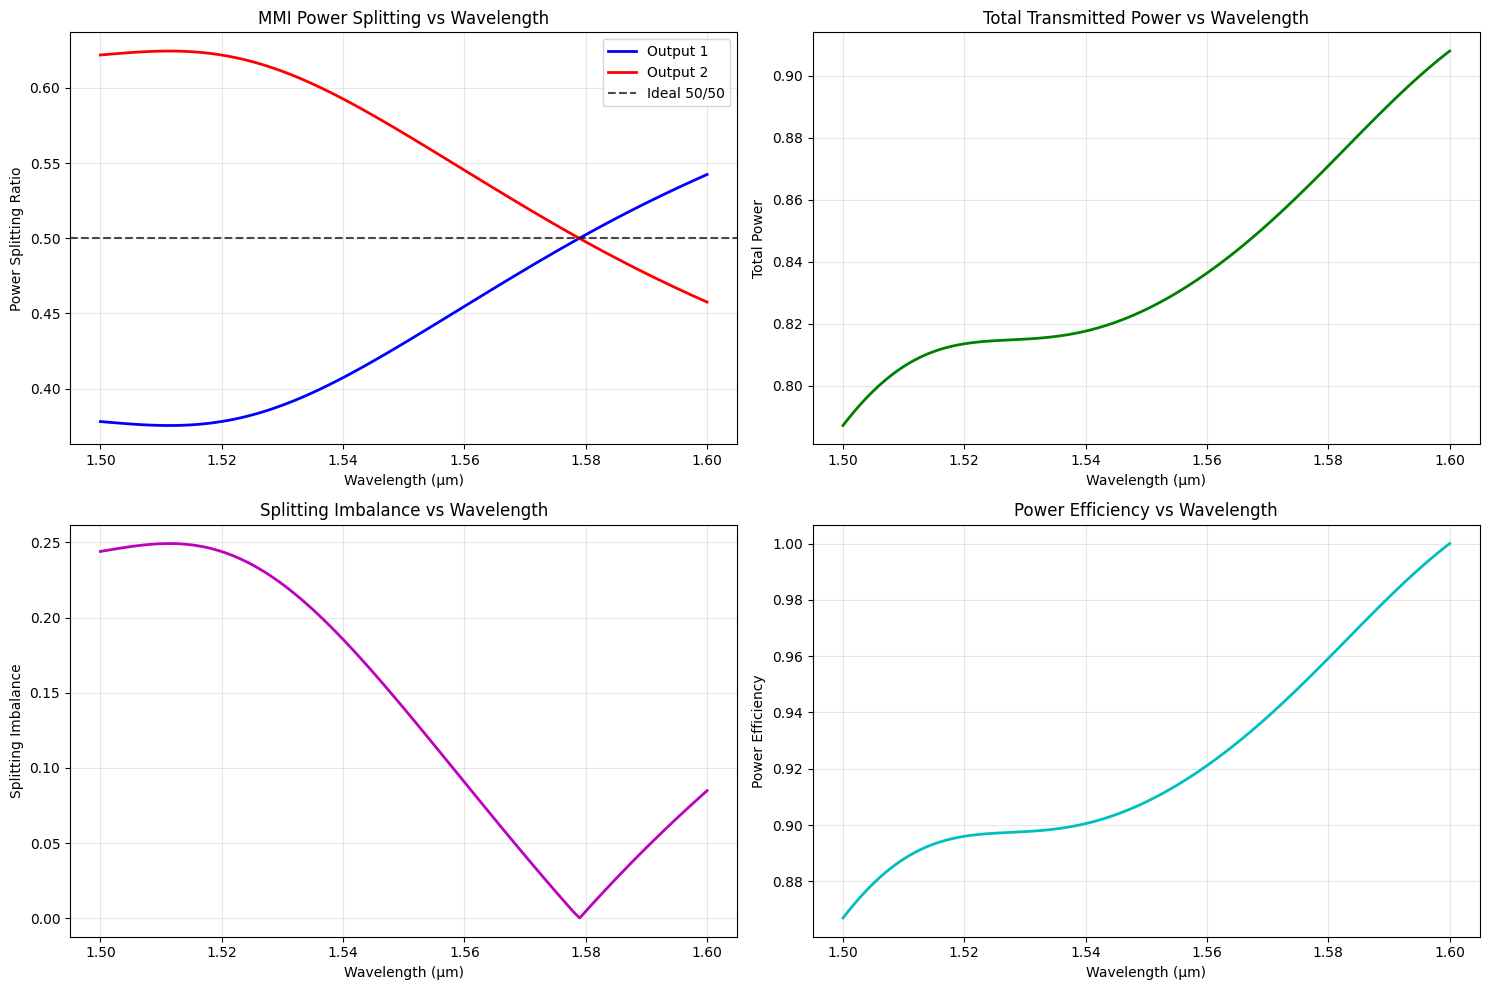

Average splitting ratio 1: 0.440
Average splitting ratio 2: 0.560
Average splitting imbalance: 0.139
Average power efficiency: 0.923


In [11]:
# Result Analysis
try:
    # Extract mode coefficients from ModeMonitors
    mode_coeff_1 = sim_data["mode_output_1"].amps.sel(mode_index=0, direction="+")
    mode_coeff_2 = sim_data["mode_output_2"].amps.sel(mode_index=0, direction="+")
    
    # Calculate power splitting
    power_1 = np.abs(mode_coeff_1)**2
    power_2 = np.abs(mode_coeff_2)**2
    total_power = power_1 + power_2
    
    # Calculate splitting ratio
    splitting_ratio_1 = power_1 / total_power
    splitting_ratio_2 = power_2 / total_power
    
    # Ensure arrays are numpy arrays for consistent indexing
    splitting_ratio_1 = np.array(splitting_ratio_1)
    splitting_ratio_2 = np.array(splitting_ratio_2)
    total_power = np.array(total_power)
    
    # Create comprehensive analysis plots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Power splitting vs wavelength
    ax1.plot(wavelengths, splitting_ratio_1, 'b-', label='Output 1', linewidth=2)
    ax1.plot(wavelengths, splitting_ratio_2, 'r-', label='Output 2', linewidth=2)
    ax1.axhline(y=0.5, color='k', linestyle='--', alpha=0.7, label='Ideal 50/50')
    ax1.set_xlabel('Wavelength (μm)')
    ax1.set_ylabel('Power Splitting Ratio')
    ax1.set_title('MMI Power Splitting vs Wavelength')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Total power vs wavelength
    ax2.plot(wavelengths, total_power, 'g-', linewidth=2)
    ax2.set_xlabel('Wavelength (μm)')
    ax2.set_ylabel('Total Power')
    ax2.set_title('Total Transmitted Power vs Wavelength')
    ax2.grid(True, alpha=0.3)
    
    # Splitting imbalance vs wavelength
    imbalance = np.abs(splitting_ratio_1 - splitting_ratio_2)
    ax3.plot(wavelengths, imbalance, 'm-', linewidth=2)
    ax3.set_xlabel('Wavelength (μm)')
    ax3.set_ylabel('Splitting Imbalance')
    ax3.set_title('Splitting Imbalance vs Wavelength')
    ax3.grid(True, alpha=0.3)
    
    # Power efficiency vs wavelength
    efficiency = total_power / total_power.max()
    ax4.plot(wavelengths, efficiency, 'c-', linewidth=2)
    ax4.set_xlabel('Wavelength (μm)')
    ax4.set_ylabel('Power Efficiency')
    ax4.set_title('Power Efficiency vs Wavelength')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print key performance metrics
    print(f"Average splitting ratio 1: {splitting_ratio_1.mean():.3f}")
    print(f"Average splitting ratio 2: {splitting_ratio_2.mean():.3f}")
    print(f"Average splitting imbalance: {imbalance.mean():.3f}")
    print(f"Average power efficiency: {efficiency.mean():.3f}")
    
except Exception as e:
    print(f"Error in result analysis: {e}")


## Field Intensity Analysis

Finally, let's examine the field intensity distribution at specific wavelengths in the XY plane to understand the light propagation through the MMI.

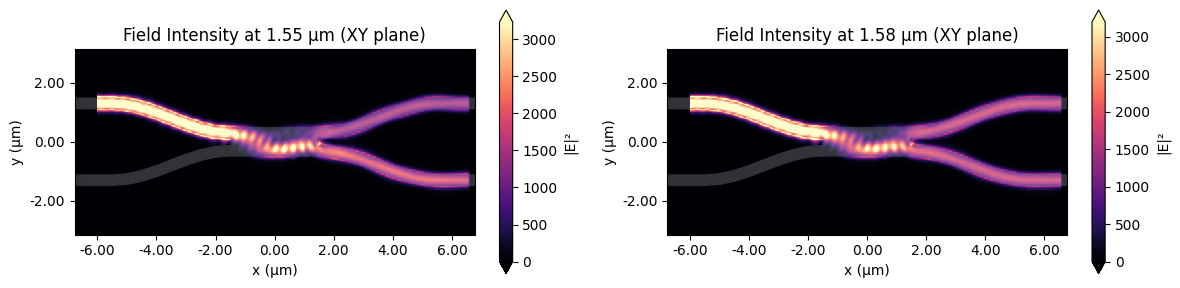

In [12]:
# Field intensity analysis.
try:
    # Create a 2x1 subplot for the two wavelengths.
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    
    # Plot field intensity at 1.55 μm using Tidy3D's built-in method.
    sim_data.plot_field("field_xy", "E", val="abs^2", f=td.C_0/1.55, ax=axes[0])
    axes[0].set_title("Field Intensity at 1.55 μm (XY plane)")
    
    # Plot field intensity at 1.58 μm using Tidy3D's built-in method.
    sim_data.plot_field("field_xy", "E", val="abs^2", f=td.C_0/1.58, ax=axes[1])
    axes[1].set_title("Field Intensity at 1.58 μm (XY plane)")
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Error in field intensity analysis: {e}")
